# Stage 5 — Ingredient Substitution Recommender

**Task:** given an ingredient `query`, suggest **N** alternatives with an explanation.

**Method:** rank candidates by a weighted score:

$$\text{score}(q, c) = \alpha \cdot \text{cos}(z_q, z_c) + (1-\alpha) \cdot \text{cos}(h_q, h_c)$$

- $z$ — GAE embeddings (graph context, stage 4)
- $h$ — chemical Morgan fingerprints (FlavorDB, stage 2)
- $\alpha = 0.6$ (tunable)

**Filters:** Jaccard coefficient (substitution context) + exclusion of the ingredient itself.
**Metrics:** Recall@K (symmetric leave-one-out on hold-out recipes) and Precision@K against a hand-crafted substitution dictionary.

**Input files:**
- `output_graphs/ingredient_embeddings.npz` (from stage 4)
- `output_graphs/node_features.npz` (chemical embeddings, stage 2)
- `output_graphs/ingredient_graph.graphml` (graph structure)
- `full_dataset.csv` (recipes used for hold-out)

In [8]:
import ast, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

OUT       = Path('output_graphs')
DATA_PATH = Path('full_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data_sample.csv')
    print(f'[!] full_dataset.csv not found, using {DATA_PATH} (smoke test, 5k rows)')
ALPHA     = 0.6    # weight of GAE embeddings vs chemical fingerprints
TOP_K     = 10     # default number of recommendations

print('Imports OK')

Imports OK


## 5.1 Loading data

In [9]:
emb_data   = np.load(OUT / 'ingredient_embeddings.npz', allow_pickle=True)
emb_nodes  = list(emb_data['nodes'])
Z_gae      = normalize(emb_data['Z'].astype(np.float32), norm='l2')

feat_data  = np.load(OUT / 'node_features.npz', allow_pickle=True)
feat_nodes = list(feat_data['nodes'])
X_chem     = normalize(feat_data['chem_matrix'].astype(np.float32), norm='l2')
has_chem   = feat_data['has_chem']

print('Loading graph I...')
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')

feat_idx = {name: i for i, name in enumerate(feat_nodes)}
gae_idx  = {name: i for i, name in enumerate(emb_nodes)}

common_nodes = sorted(set(emb_nodes) & set(feat_nodes))
Z_g = np.stack([Z_gae[gae_idx[n]]   for n in common_nodes])  # (N, 64)
Z_c = np.stack([X_chem[feat_idx[n]] for n in common_nodes])  # (N, 512)
node2idx = {n: i for i, n in enumerate(common_nodes)}

SIM_G = cosine_similarity(Z_g)   # (N, N)
SIM_C = cosine_similarity(Z_c)   # (N, N)

print(f'Ingredients with full embeddings: {len(common_nodes):,}')
print(f'Z_g shape: {Z_g.shape},  Z_c shape: {Z_c.shape}')
print(f'SIM_G shape: {SIM_G.shape},  SIM_C shape: {SIM_C.shape}')

Loading graph I...
Ingredients with full embeddings: 7,199
Z_g shape: (7199, 64),  Z_c shape: (7199, 512)
SIM_G shape: (7199, 7199),  SIM_C shape: (7199, 7199)


## 5.2 Recommendation function

In [10]:
def recommend_substitutes(
    query: str,
    top_k: int = TOP_K,
    alpha: float = ALPHA,
    context: list | None = None,
    exclude_connected: bool = False,
) -> pd.DataFrame:
    """
    Return top_k substitutes for the query ingredient.

    score(q,c) = alpha * cos(Z_g[q], Z_g[c])   (graph context, GAE)
               + (1-alpha) * cos(Z_c[q], Z_c[c]) (chemical similarity)
    """
    if query not in node2idx:
        from difflib import get_close_matches
        hits = get_close_matches(query, common_nodes, n=1, cutoff=0.7)
        if hits:
            print(f'  (auto-correction: "{query}" → "{hits[0]}")')
            query = hits[0]
        else:
            print(f'  Ingredient "{query}" not found in the dictionary')
            return pd.DataFrame()

    idx = node2idx[query]

    gae_sim  = SIM_G[idx]   # (N,)
    chem_sim = SIM_C[idx]   # (N,)
    sims     = alpha * gae_sim + (1 - alpha) * chem_sim

    jaccard_bonus = np.zeros(len(common_nodes), dtype=np.float32)
    if context and query in I:
        for i, cand in enumerate(common_nodes):
            if cand in I:
                c_neighbors = set(I.neighbors(cand))
                ctx_set = set(context)
                inter = len(c_neighbors & ctx_set)
                union = len(c_neighbors | ctx_set)
                jaccard_bonus[i] = inter / union if union > 0 else 0.0

    final_score = sims + 0.2 * jaccard_bonus
    final_score[idx] = -1.0

    if exclude_connected and query in I:
        for nbr in I.neighbors(query):
            if nbr in node2idx:
                final_score[node2idx[nbr]] -= 0.5

    top_indices = np.argsort(-final_score)[:top_k]

    rows = []
    for rank, i in enumerate(top_indices, 1):
        cand = common_nodes[i]
        cooc = I[query][cand].get('weight', 0) if I.has_edge(query, cand) else 0
        rows.append({
            'Rank'      : rank,
            'Substitute': cand,
            'Score'     : round(float(final_score[i]), 4),
            'GAE_sim'   : round(float(gae_sim[i]),  4),
            'Chem_sim'  : round(float(chem_sim[i]), 4),
            'Jaccard+'  : round(float(jaccard_bonus[i]), 4),
            'CoOccur'   : int(cooc),
        })

    return pd.DataFrame(rows).set_index('Rank')


print('Function recommend_substitutes is defined')

Function recommend_substitutes is defined


## 5.3 Demonstration

In [11]:
queries = [
    ('butter', ['flour', 'sugar', 'eggs', 'milk']),      # baking → butter substitute
    ('chicken', ['onion', 'garlic', 'tomato', 'rice']),  # main course
    ('parsley', None),                                    # herbs without context
    ('cream cheese', ['bagel', 'lox', 'capers']),        # breakfast
]

for q, ctx in queries:
    print(f'\n{"="*60}')
    print(f'Query: "{q}"')
    if ctx:
        print(f'Recipe context: {ctx}')
    df = recommend_substitutes(q, top_k=8, context=ctx)
    print(df.to_string())


Query: "butter"
Recipe context: ['flour', 'sugar', 'eggs', 'milk']
           Substitute   Score  GAE_sim  Chem_sim  Jaccard+  CoOccur
Rank                                                               
1                milk  0.9924   0.9956    0.9874    0.0007   131134
2        cream cheese  0.9398   0.9293    0.9546    0.0017    31553
3             vanilla  0.9364   0.9741    0.8789    0.0016   118919
4     unsalted butter  0.9325   0.8870    1.0000    0.0017     4386
5           olive oil  0.9325   0.9750    0.8684    0.0009    25897
6       weight butter  0.9292   0.8479    1.0000    0.1026       41
7              garlic  0.9275   0.9976    0.8220    0.0008    54798
8               onion  0.9261   0.9894    0.8307    0.0008    69576

Query: "chicken"
Recipe context: ['onion', 'garlic', 'tomato', 'rice']
                 Substitute   Score  GAE_sim  Chem_sim  Jaccard+  CoOccur
Rank                                                                     
1             chicken broth  0.9

## 5.4 Effect of alpha on recommendations

We inspect how the top-5 changes when balancing graph context vs chemistry.

In [12]:
def recommend_alpha(query: str, alpha: float, top_k: int = 5) -> list:
    if query not in node2idx:
        return []
    idx  = node2idx[query]
    sims = alpha * SIM_G[idx] + (1 - alpha) * SIM_C[idx]
    sims[idx] = -1.0
    top = np.argsort(-sims)[:top_k]
    return [common_nodes[i] for i in top]


test_query = 'butter'
print(f'Substitutes for "{test_query}" across alpha values (0=chem only, 1=graph only):\n')
print(f'{"alpha":<8}', '  '.join(f'#{i+1}' for i in range(5)))
print('-' * 65)
for a in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    recs = recommend_alpha(test_query, alpha=a)
    row  = '  '.join(f'{r:<12}' for r in recs)
    print(f'{a:<8.1f}  {row}')

Substitutes for "butter" across alpha values (0=chem only, 1=graph only):

alpha    #1  #2  #3  #4  #5
-----------------------------------------------------------------
0.0       buttered cracker crumbs  butter flavor  butter crackers  cold unsalted butter  butterscotch bits
0.2       milk          unsalted butter  weight butter  butterscotch pudding  nonfat buttermilk
0.4       milk          unsalted butter  cream cheese  weight butter  cheddar cheese
0.6       milk          cream cheese  vanilla       olive oil     unsalted butter
0.8       milk          garlic        onion         vanilla       olive oil   
1.0       water         flour         garlic        eggs          milk        


## 5.5 Quality evaluation: Recall@K (symmetric leave-one-out)

**Procedure:** on hold-out recipes we randomly hide an ingredient **X**.  
The remaining ingredients are the context. **Hit@K:** the hidden **X** appears in the top-K recommendations for *some* remaining **Y** (with context = recipe minus Y).  
This way the metric reflects "X is similar to what it co-occurs with" rather than "any ingredient in the recipe is in the top-K substitutes for X".

## 5.5b Precision@K against a hand-crafted substitution dictionary

Mean fraction of positions in the top-K occupied by candidates from a hand-crafted list of acceptable substitutes (useful for reports / comparison with the literature).

In [13]:
print('Loading hold-out recipes...')
df_holdout = pd.read_csv(
    DATA_PATH,
    usecols=['NER'],
    skiprows=range(1, 195_001),  # skip the first 195k rows
    nrows=5_000
)
df_holdout['ner_list'] = df_holdout['NER'].apply(ast.literal_eval)

known = set(common_nodes)
df_holdout['known_ings'] = df_holdout['ner_list'].apply(
    lambda lst: [x for x in lst if x in known]
)
df_holdout = df_holdout[df_holdout['known_ings'].apply(len) >= 3]
print(f'Hold-out recipes: {len(df_holdout):,}')

Loading hold-out recipes...
Hold-out recipes: 4,804


In [14]:
def recall_at_k(df: pd.DataFrame, k_values=(5, 10, 20), n_sample=2000, seed=42):
    """
    Symmetric leave-one-out:
      - hide target X; remaining = recipe without X
      - for each k: hit if there exists Y in remaining such that
        X is in top-k recommend_substitutes(Y, context=remaining \\ {Y})
    """
    rng = np.random.default_rng(seed)
    recipes = df['known_ings'].tolist()
    if n_sample < len(recipes):
        recipes = [recipes[i] for i in rng.choice(len(recipes), n_sample, replace=False)]

    hits  = {k: 0 for k in k_values}
    total = 0
    t0    = time.time()

    for recipe in recipes:
        if len(recipe) < 2:
            continue
        ti     = rng.integers(0, len(recipe))
        target = recipe[ti]
        remaining = [x for j, x in enumerate(recipe) if j != ti]

        for k in k_values:
            hit = False
            for y in remaining:
                if y not in node2idx:
                    continue
                ctx_y = [z for z in remaining if z != y]
                recs_df = recommend_substitutes(
                    y, top_k=k, context=ctx_y if ctx_y else None,
                )
                if not recs_df.empty and target in set(recs_df['Substitute']):
                    hit = True
                    break
            if hit:
                hits[k] += 1
        total += 1

    elapsed = time.time() - t0
    recalls = {k: hits[k] / total for k in k_values}
    print(f'\nRecall@K (symmetric LOO) on {total} recipes ({elapsed:.1f}s):')
    for k, r in recalls.items():
        print(f'  Recall@{k:<3} = {r:.4f} ({hits[k]}/{total})')
    return recalls


recalls = recall_at_k(df_holdout, k_values=[5, 10, 20], n_sample=1000)


Recall@K (symmetric LOO) on 1000 recipes (1670.8s):
  Recall@5   = 0.2410 (241/1000)
  Recall@10  = 0.3260 (326/1000)
  Recall@20  = 0.4200 (420/1000)


In [15]:
SUBSTITUTION_GT = {
    'butter': ['margarine', 'coconut oil', 'vegetable shortening', 'ghee'],
    'milk': ['almond milk', 'oat milk', 'soy milk', 'coconut milk'],
    'chicken': ['turkey', 'tofu', 'chickpeas', 'tempeh'],
    'sour cream': ['greek yogurt', 'creme fraiche', 'plain yogurt'],
    'breadcrumbs': ['panko', 'crushed crackers', 'oats', 'almond flour'],
    'heavy cream': ['coconut cream', 'evaporated milk', 'half and half'],
    'parsley': ['cilantro', 'basil', 'chervil', 'tarragon'],
    'lemon juice': ['lime juice', 'white wine vinegar', 'apple cider vinegar'],
    'olive oil': ['vegetable oil', 'canola oil', 'sunflower oil', 'avocado oil'],
    'sugar': ['honey', 'maple syrup', 'agave nectar', 'coconut sugar'],
}


def precision_at_k(gt_dict, recommend_fn, k_values=(5, 10), alpha: float = ALPHA):
    results = {k: [] for k in k_values}
    for query, ground_truth in gt_dict.items():
        if query not in node2idx:
            continue
        gt_set = {g for g in ground_truth if g in node2idx}
        if not gt_set:
            continue
        for k in k_values:
            recs = recommend_fn(query, top_k=k, alpha=alpha, context=None)
            if recs.empty:
                continue
            hits = sum(1 for r in recs['Substitute'] if r in gt_set)
            results[k].append(hits / k)

    print(f'Precision@K over {len(gt_dict)} queries (only when query and at least one substitute are in the vocabulary):')
    means = {}
    for k in k_values:
        vals = results[k]
        if vals:
            means[k] = float(np.mean(vals))
            n_pos = sum(1 for v in vals if v > 0)
            print(f'  P@{k:<3} = {means[k]:.4f}  (at least one hit in {n_pos}/{len(vals)} queries)')
        else:
            means[k] = 0.0
            print(f'  P@{k:<3} = n/a (no valid queries)')
    return means


_gt_means = precision_at_k(SUBSTITUTION_GT, recommend_substitutes)
p_gt5 = _gt_means.get(5, 0.0)
p_gt = _gt_means.get(10, 0.0)

Precision@K over 10 queries (only when query and at least one substitute are in the vocabulary):
  P@5   = 0.0000  (at least one hit in 0/10 queries)
  P@10  = 0.0000  (at least one hit in 0/10 queries)


## 5.6 Ablation: GAE-only vs Chem-only vs Combined


Ablation — Recall@10 vs alpha:
  alpha=0.0  0.0080  
  alpha=0.2  0.2840  ███████████
  alpha=0.4  0.2960  ███████████
  alpha=0.6  0.3260  █████████████
  alpha=0.8  0.3600  ██████████████
  alpha=1.0  0.3860  ███████████████


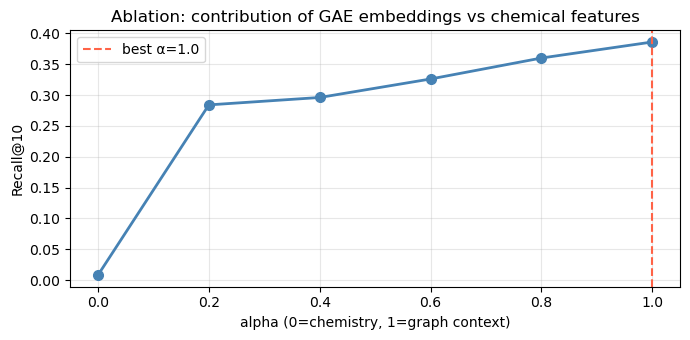


Optimal alpha = 1.0


In [16]:
def recall_alpha(df, alpha_val, k=10, n_sample=500, seed=42):
    rng     = np.random.default_rng(seed)
    recipes = df['known_ings'].tolist()
    if n_sample < len(recipes):
        recipes = [recipes[i] for i in rng.choice(len(recipes), n_sample, replace=False)]

    hits  = 0
    total = 0
    for recipe in recipes:
        if len(recipe) < 2:
            continue
        ti       = rng.integers(0, len(recipe))
        target   = recipe[ti]
        remaining = [x for j, x in enumerate(recipe) if j != ti]
        if target not in node2idx:
            continue
        hit = False
        for y in remaining:
            if y not in node2idx:
                continue
            iy = node2idx[y]
            sims = alpha_val * SIM_G[iy] + (1 - alpha_val) * SIM_C[iy]
            sims[iy] = -1.0
            top = [common_nodes[i] for i in np.argsort(-sims)[:k]]
            if target in top:
                hit = True
                break
        if hit:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0.0


alphas  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
recall_k10 = [recall_alpha(df_holdout, a, k=10, n_sample=500) for a in alphas]

print('\nAblation — Recall@10 vs alpha:')
for a, r in zip(alphas, recall_k10):
    bar = '█' * int(r * 40)
    print(f'  alpha={a:.1f}  {r:.4f}  {bar}')

plt.figure(figsize=(7, 3.5))
plt.plot(alphas, recall_k10, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.xlabel('alpha (0=chemistry, 1=graph context)')
plt.ylabel('Recall@10')
plt.title('Ablation: contribution of GAE embeddings vs chemical features')
plt.grid(alpha=0.3)
best_a = alphas[np.argmax(recall_k10)]
plt.axvline(best_a, color='tomato', linestyle='--', label=f'best α={best_a}')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'substitution_alpha_ablation.png', dpi=120)
plt.show()
print(f'\nOptimal alpha = {best_a}')

## 5.7 Interactive mode

Inspect any ingredient.

In [17]:
QUERY   = 'olive oil'
CONTEXT = ['tomato', 'garlic', 'basil', 'pasta']
K       = 10

print(f'Substitutes for "{QUERY}"')
print(f'Context: {CONTEXT}\n')
df_result = recommend_substitutes(QUERY, top_k=K, context=CONTEXT)
print(df_result.to_string())

Substitutes for "olive oil"
Context: ['tomato', 'garlic', 'basil', 'pasta']

                  Substitute   Score  GAE_sim  Chem_sim  Jaccard+  CoOccur
Rank                                                                      
1                   tomatoes  0.9881   0.9912    0.9830    0.0011    44629
2                      onion  0.9850   0.9968    0.9671    0.0008    52004
3                     garlic  0.9788   0.9868    0.9666    0.0006   112557
4                lemon juice  0.9702   0.9875    0.9438    0.0010    25203
5                   cinnamon  0.9621   0.9774    0.9384    0.0017     3234
6     extra-virgin olive oil  0.9574   0.9282    1.0000    0.0024     1605
7                     onions  0.9530   0.9431    0.9671    0.0014    13721
8                     pepper  0.9512   0.9769    0.9121    0.0011    28584
9                     celery  0.9461   0.9512    0.9377    0.0014    10925
10                      milk  0.9435   0.9890    0.8750    0.0009    10963


## 5.8 Visualization: substitution graph for top ingredients

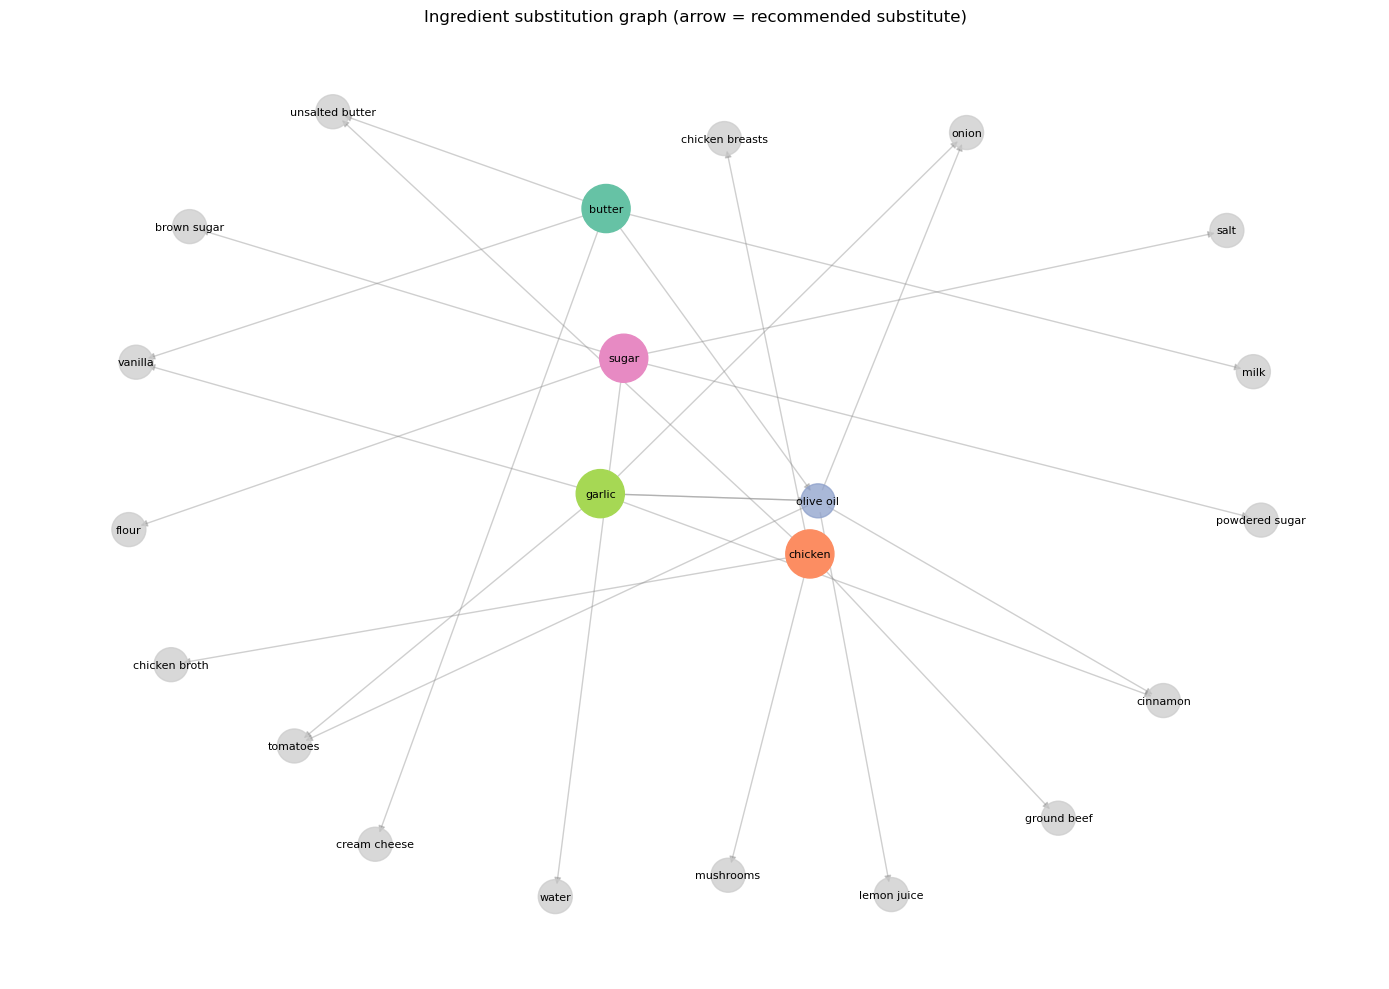

In [18]:
focus_ingredients = ['butter', 'chicken', 'olive oil', 'sugar', 'garlic']
K_viz = 5

G_sub = nx.DiGraph()
colors = {}
palette = plt.cm.Set2.colors

for ci, query_ing in enumerate(focus_ingredients):
    if query_ing not in node2idx:
        continue
    G_sub.add_node(query_ing, kind='query')
    colors[query_ing] = palette[ci % len(palette)]

    recs = recommend_substitutes(query_ing, top_k=K_viz)
    if recs.empty:
        continue
    for _, row in recs.iterrows():
        cand = row['Substitute']
        G_sub.add_node(cand, kind='substitute')
        if cand not in colors:
            colors[cand] = '#cccccc'
        G_sub.add_edge(query_ing, cand, weight=row['Score'])

pos = nx.spring_layout(G_sub, k=1.5, seed=42)
fig, ax = plt.subplots(figsize=(14, 10))

query_nodes = [n for n, d in G_sub.nodes(data=True) if d.get('kind') == 'query']
sub_nodes   = [n for n, d in G_sub.nodes(data=True) if d.get('kind') != 'query']

nx.draw_networkx_nodes(G_sub, pos, nodelist=query_nodes,
                       node_color=[colors[n] for n in query_nodes],
                       node_size=1200, ax=ax)
nx.draw_networkx_nodes(G_sub, pos, nodelist=sub_nodes,
                       node_color=[colors[n] for n in sub_nodes],
                       node_size=600, alpha=0.75, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.4, ax=ax,
                       arrows=True, arrowsize=10, edge_color='#888')
nx.draw_networkx_labels(G_sub, pos, font_size=8, ax=ax)

ax.set_title('Ingredient substitution graph (arrow = recommended substitute)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'substitution_graph.png', dpi=120)
plt.show()

## 5.9 Saving results

In [19]:
summary = {
    'recall': recalls,
    'precision_ground_truth@5': float(p_gt5),
    'precision_ground_truth@10': float(p_gt),
    'best_alpha': float(alphas[np.argmax(recall_k10)]),
    'alpha_sweep': {str(a): r for a, r in zip(alphas, recall_k10)},
    'n_ingredients': len(common_nodes),
}
with open(OUT / 'substitution_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved:')
for fname in ['substitution_summary.json', 'substitution_alpha_ablation.png',
              'substitution_graph.png']:
    p = OUT / fname
    if p.exists():
        print(f'  {fname:<45} {p.stat().st_size/1e3:.0f} KB')

print('\n=== Stage 5 summary ===')
print(f'Recall@5  = {recalls.get(5, "N/A")}')
print(f'Recall@10 = {recalls.get(10, "N/A")}')
print(f'Recall@20 = {recalls.get(20, "N/A")}')
print(f'Best alpha = {summary["best_alpha"]}')
print(f'Precision@5  (dictionary) = {summary["precision_ground_truth@5"]}')
print(f'Precision@10 (dictionary) = {summary["precision_ground_truth@10"]}')

Saved:
  substitution_summary.json                     0 KB
  substitution_alpha_ablation.png               42 KB
  substitution_graph.png                        188 KB

=== Stage 5 summary ===
Recall@5  = 0.241
Recall@10 = 0.326
Recall@20 = 0.42
Best alpha = 1.0
Precision@5  (dictionary) = 0.0
Precision@10 (dictionary) = 0.0
